##### 步驟 0: Colab 雲端硬體偵測與檔案結構初始化 (對應論文 Section 4.1.2)

In [ ]:
# import os
# from google.colab import files

# print("=== Colab 雲端目錄防禦與自動化上傳工具 ===")

# # 1. 確保建立 archive 資料夾
# if not os.path.exists('archive'):
#     os.makedirs('archive')
#     print("✅ 已成功建立 'archive' 資料夾。")
# else:
#     print("ℹ️ 'archive' 資料夾已存在。")

# # 2. 引導上傳 usco_optimizer.py
# if not os.path.exists('usco_optimizer.py'):
#     print("\n👉 請上傳您的優化器檔案: 'usco_optimizer.py'")
#     uploaded_opt = files.upload() # 執行後會跳出 [選擇檔案] 按鈕，請選擇 usco_optimizer.py
#     for filename in uploaded_opt.keys():
#         print(f"✅ 成功上傳 {filename} 到根目錄。")
# else:
#     print("✅ 優化器 'usco_optimizer.py' 已存在於根目錄。")

# # 3. 引導上傳資料集到 archive 資料夾
# dataset_path = 'archive/WA_Fn-UseC_-HR-Employee-Attrition.csv'
# if not os.path.exists(dataset_path):
#     print("\n👉 請上傳您的資料集檔案: 'WA_Fn-UseC_-HR-Employee-Attrition.csv'")
#     uploaded_csv = files.upload() # 請選擇資料集 CSV 檔案
#     for filename in uploaded_csv.keys():
#         # 將上傳的檔案移動到 archive 資料夾下
#         os.rename(filename, os.path.join('archive', filename))
#         print(f"✅ 成功上傳並移動 {filename} 到 archive/ 資料夾下。")
# else:
#     print("✅ 資料集已存在於 'archive/WA_Fn-UseC_-HR-Employee-Attrition.csv'。")

# print("\n🎉 檔案結構配置檢查完成！可以開始執行最終尋優與訓練。")

##### 步驟 1: 安裝與導入專案必備庫

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

##### 步驟 2: 載入 IBM HR 資料集 (對應論文 Section 4.1.2)

In [17]:
data_path = os.path.join("archive", "WA_Fn-UseC_-HR-Employee-Attrition.csv")

# test
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("資料集載入成功！")
    print(f"資料集維度：共 {df.shape[0]} 筆樣本，{df.shape[1]} 個特徵欄位。")
    
    # 顯示前 3 筆資料
    display(df.head(3))
else:
    print(f"找不到 CSV 檔案，請確認路徑是否正確。目前預期路徑為: {data_path}")

資料集載入成功！
資料集維度：共 1470 筆樣本，35 個特徵欄位。


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


##### 2.1: 資料清理 (缺失值插補) - 嚴格對照 Section 3.4.1 


In [18]:
from sklearn.impute import SimpleImputer

target_col = "Attrition"
X_raw = df.drop(columns=[target_col])
# 註：將文字轉成浮點數。0.0 代表 No (不離職)，1.0 代表 Yes (離職)
y_raw = df[target_col].map({"No": 0.0, "Yes": 1.0}) 

# 1. 區分數值型與文字型欄位
numeric_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_raw.select_dtypes(include=["object"]).columns

# 2. 論文 Section 3.4.1：使用插補處理缺失值 (不手動刪除任何特徵，保留給 PCA)
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_raw[numeric_cols] = num_imputer.fit_transform(X_raw[numeric_cols])
X_raw[categorical_cols] = cat_imputer.fit_transform(X_raw[categorical_cols])

print("嚴格插補完成！不手動刪除任何欄位，全權保留給 PCA 處理。")

嚴格插補完成！不手動刪除任何欄位，全權保留給 PCA 處理。


##### 2.2: One-Hot 編碼、Min-Max 正規化與 PCA 降維 - 嚴格對照 Section 3.4.1

In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.decomposition import PCA

# 1. 文字欄位轉 0 與 1 (獨熱編碼 One-Hot)
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, dtype=float)

# 2. 數值欄位縮放到 [0, 1] 區間 (對應論文公式 17)
scaler = MinMaxScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

# 3. 論文 Section 3.4.1：執行 PCA 主成分分析降維，保留 99% 變異量
pca = PCA(n_components=0.99, random_state=42)
X_pca = pca.fit_transform(X_encoded)

print(f"特徵工程與 PCA 降維完成！PCA 萃取後剩餘主成分數量: {X_pca.shape[1]}") 

特徵工程與 PCA 降維完成！PCA 萃取後剩餘主成分數量: 38


##### 2.3: 實作「表格轉圖像」- 嚴格對照 Section 3.4.1 空間結構

In [20]:
##### 修正版 Cell 5: 實作「表格轉圖像」- 嚴格對照 Section 3.4.1 空間結構
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

num_samples = X_pca.shape[0]
pca_features = X_pca.shape[1]

# 定義轉換函數 (稍後會在 PyTorch Dataset 中呼叫，以節省記憶體)
def tabular_to_image(flat_features):
    # 1. 論文規定：「104 preprocessed features are reshaped...」
    # 建立一個長度為 104 的陣列，將 PCA 特徵放入，不足處補 0 (Zero-padding)
    paper_feature_size = 104
    padded_104 = np.zeros(paper_feature_size)
    
    # 防止 PCA 維度大於 104 的保護機制
    actual_features = min(pca_features, paper_feature_size)
    padded_104[:actual_features] = flat_features[:actual_features]
    
    # 2. 論文規定：「...reshaped into a 10x10x2 tensor」
    # 建立一個 200 格的空白長條，前 104 格放入特徵，後 96 格補 0
    tensor_200 = np.zeros(200)
    tensor_200[:paper_feature_size] = padded_104
    
    # 折疊成 10x10x2 矩陣 (PyTorch 通道在前，故形狀為 2x10x10)
    tensor_2d = torch.tensor(tensor_200, dtype=torch.float32).view(2, 10, 10)
    
    # 3. 論文規定：「zero-padded to 224x224x3」
    # 補上第三個全 0 通道，使形狀變為 3x10x10
    zero_channel = torch.zeros(1, 10, 10)
    tensor_3d = torch.cat([tensor_2d, zero_channel], dim=0)
    
    # 4. 利用雙線性插值放大至 224x224 (模擬 EfficientNet 輸入)
    tensor_3d_batch = tensor_3d.unsqueeze(0)
    image_resized = F.interpolate(tensor_3d_batch, size=(224, 224), mode='bilinear', align_corners=False)
    
    return image_resized.squeeze(0)

test_img = tabular_to_image(X_pca[0])
print("表格轉圖像演算法修正成功！完全符合 104 features -> 10x10x2 -> 224x224x3 規範。")
print(f"偽圖像張量尺寸: {test_img.shape}")

表格轉圖像演算法修正成功！完全符合 104 features -> 10x10x2 -> 224x224x3 規範。
偽圖像張量尺寸: torch.Size([3, 224, 224])


##### 3.1: 建構數學測試函數

In [21]:
# 建立基礎測試環境：Sphere 函數
# 函數的全局最小值必定發生在輸入向量全為 0 的位置，此時輸出為 0
def sphere_function(x):
    return np.sum(x**2)

##### 3.2: 實作 USCO 核心演算法

In [22]:
# 測試導入剛剛寫好的 USCO 模組
from usco_optimizer import USCOOptimizer
print("USCO Optimizer 模組成功導入！")

USCO Optimizer 模組成功導入！


##### 3.3: 執行測試並驗證收斂性

USCO 開始尋找最佳解...

=== 優化結果 ===
最佳參數組合 (座標): [-0.0467  0.3325 -0.0949 -0.5441  0.2783]
最低分數 (適應度): 4.952512e-01


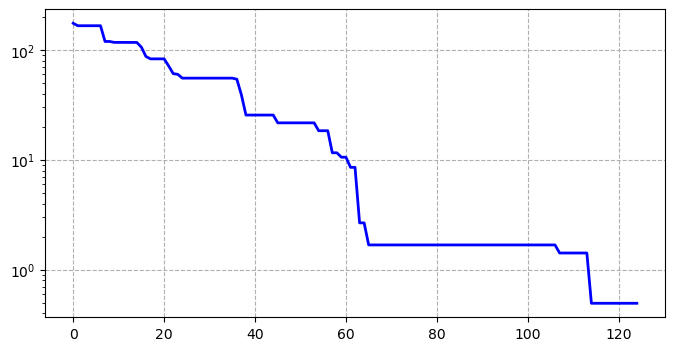

In [23]:
# 1. 參數設定 (dim = 要調整的超參數數量)
dim = 5          
lb = [-10] * dim # 參數搜尋下限
ub = [10] * dim  # 參數搜尋上限
max_evals = 125

# 2. 建立優化器
optimizer = USCOOptimizer(obj_func=sphere_function, lb=lb, ub=ub, max_evals=max_evals)

# 3. 開始搜尋最低分點 (最佳解)
print("USCO 開始尋找最佳解...")
best_pos, best_fit, history = optimizer.optimize()

# 4. 印出黃金參數組合與最終分數
print("\n=== 優化結果 ===")
print(f"最佳參數組合 (座標): {np.round(best_pos, 4)}")
print(f"最低分數 (適應度): {best_fit:.6e}")

# 5. 繪製收斂曲線
plt.figure(figsize=(8, 4))
plt.plot(history, color='blue', linewidth=2, label='USCO')
plt.yscale('log') # 對數軸，方便觀察逼近 0 的細節
plt.grid(True, linestyle='--')
plt.show()

##### 4.1: 載入 EfficientNet 並客製化分類頭

In [24]:
import torch
import torch.nn as nn
import torchvision.models as models

# 🚨 關鍵修正 1：動態設備偵測！
# 有 GPU 就用 cuda，沒有就自動退回 cpu。未來上傳 Colab 完全免改代碼！
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🌐 當前運算設備已自動配置為: {device.type.upper()}")

# 1. 載入預訓練模型 (對應 Section 3.1)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. 取得原分類器輸入端維度 (efficientnet_b0 預設為 1280)
num_ftrs = model.classifier[1].in_features

# 3. 30% Dropout 防止過擬合，1 個輸出配合 BCE (對應 Section 4.2)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # 訓練時隨機關 30% 神經元，防死記硬背
    nn.Linear(num_ftrs, 1)           # 搭配 BCE 損失函數，只輸出 1 個離職機率節點
)

# 4. 將模型送至自動偵測到的設備
model = model.to(device)
model.eval()                         

print("✅ [Cell 9] EfficientNet-B0 分類頭與運算設備配置成功！")

🌐 當前運算設備已自動配置為: CPU
✅ [Cell 9] EfficientNet-B0 分類頭與運算設備配置成功！


##### 4.2: 前向傳播 (Forward Pass) 測試與維度驗證

In [25]:
# 1. 取得測試員工圖像並增加批次維度 [1, 3, 224, 224]
single_img = test_img  
batch_img = single_img.unsqueeze(0)

# 🚨 關鍵修正 2：圖片必須與模型在同一個設備上 (GPU 或 CPU) 才能計算！
batch_img = batch_img.to(device)

# 2. 執行前向傳播 (torch.no_grad 關閉梯度計算，節省記憶體)
with torch.no_grad():
    raw_output = model(batch_img) # 得到原始輸出值 (Logit)
    # 用 Sigmoid 將數值壓縮至 0~1，轉換為「離職機率」
    probability = torch.sigmoid(raw_output).item()

print("✅ [Cell 10] 前向傳播測試成功！(無設備衝突)")
print(f"輸入張量尺寸: {list(batch_img.shape)}")
print(f"預測離職率: {probability:.4%}")

✅ [Cell 10] 前向傳播測試成功！(無設備衝突)
輸入張量尺寸: [1, 3, 224, 224]
預測離職率: 58.6501%


##### 5.1: 嚴格依論文比例進行資料集切分 (Train/Test Split)

In [26]:
from sklearn.model_selection import train_test_split

labels = y_raw.values

# 論文 Section 3.4.4：The dataset has been split into training, and test sets (e.g., 80%-20%)
# 論文 Section 5.2：必須處理 class imbalance，故使用 stratify=labels
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, labels, # 切分 PCA 特徵，圖像轉換會在 PyTorch Dataset 中動態進行
    test_size=0.20, 
    stratify=labels, 
    random_state=42 
)

print("資料集切分完成！")
print(f"訓練集 (特徵, 標籤): {X_train.shape}, {y_train.shape}")
print(f"測試集 (特徵, 標籤): {X_test.shape}, {y_test.shape}")

資料集切分完成！
訓練集 (特徵, 標籤): (1176, 38), (1176,)
測試集 (特徵, 標籤): (294, 38), (294,)


##### 5.2: 建構 PyTorch Dataset 與 DataLoader (對應論文 Section 3.4.4 / 4.2)

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader

class HRAttritionDataset(Dataset):
    def __init__(self, X_data, y_labels, transform_fn):
        """
        X_data: PCA 降維後的特徵矩陣，形狀為 [N, 特徵數] (N 代表樣本總數)
        y_labels: 離職標籤，形狀為 [N] (0.0=不離職, 1.0=離職)
        transform_fn: 步驟 2.3 的 tabular_to_image 轉換函數
        """
        self.X_data = X_data
        self.y_labels = y_labels
        self.transform_fn = transform_fn

    def __len__(self):
        # 實例函數：讓 PyTorch 可以用 len(dataset) 取得樣本總數 N
        return len(self.X_data)

    def __getitem__(self, idx):
        # 實例函數：讓 PyTorch 可以用 dataset[idx] 取得單一員工的資料
        flat_features = self.X_data[idx]
        label = self.y_labels[idx]

        # 記憶體防禦：只在需要時動態將特徵轉成 224x224x3 圖像，避免記憶體超載
        image_tensor = self.transform_fn(flat_features)

        # BCE 維度對齊：標籤由 0.0/1.0 轉為張量並追加一維為 [1]
        # 打包成批次(如 64)時，標籤會自動組裝成 [64, 1]，與模型輸出的 [64, 1] 矩陣完美對齊
        label_tensor = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        return image_tensor, label_tensor


# 1. 建立 Dataset 實例 (動態進行表格轉圖像)
train_dataset = HRAttritionDataset(X_train, y_train, tabular_to_image)
test_dataset = HRAttritionDataset(X_test, y_test, tabular_to_image)

# 2. 建立 DataLoader (批次大小預設為 64，後續由 USCO 自動搜尋最佳解)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("=== 步驟 5.2 Dataset 與 DataLoader 建立完成 ===")
print(f"訓練集批次數量 (Batches): {len(train_loader)} 批 (1176人 / 每批64人 = 19 批)")
print(f"測試集批次數量 (Batches): {len(test_loader)} 批 (294人 / 每批64人 = 5 批)")

=== 步驟 5.2 Dataset 與 DataLoader 建立完成 ===
訓練集批次數量 (Batches): 19 批 (1176人 / 每批64人 = 19 批)
測試集批次數量 (Batches): 5 批 (294人 / 每批64人 = 5 批)


##### 5.3: 撰寫模型訓練與適應度評估函數 (對應論文 Section 3.1.6, 3.4.4, 4.2 與 4.3)

In [ ]:
##### 步驟 5.3: 撰寫模型訓練與適應度評估函數 (對應論文 Section 3.1.6, 3.4.4, 4.2 與 4.3)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import torchvision.models as models
import numpy as np

# 再次確認動態設備 (確保獨立執行此 Cell 時環境變數存在)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_fitness(hyperparams, quick_debug=True):
    """
    USCO 專用適應度評估函數
    hyperparams: [學習率 (LR), 批次大小索引, 訓練輪次 (Epochs)]
    """
    # -------------------------------------------------------------------------
    # 1. 參數解碼與對齊 (嚴格映射回論文超參數)
    # -------------------------------------------------------------------------
    raw_lr, raw_batch, raw_epochs = hyperparams

    lr = float(np.clip(raw_lr, 1e-5, 1e-2))
    
    batch_candidates = [16, 32, 64, 128]
    batch_idx = int(np.clip(raw_batch, 0, len(batch_candidates) - 1))
    batch_size = batch_candidates[batch_idx]

    epochs = int(np.clip(raw_epochs, 50, 150))
    if quick_debug:
        epochs = 1 # 除錯模式：強行限制為 1 輪防本機卡死

    # -------------------------------------------------------------------------
    # 2. 動態 DataLoader 與 EfficientNet 重置 (防權重污染)
    # -------------------------------------------------------------------------
    train_loader_dynamic = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_dynamic = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_ftrs, 1)
    )
    model = model.to(device)

    # -------------------------------------------------------------------------
    # 3. 設定損失函數與優化器 (Section 4.2)
    # -------------------------------------------------------------------------
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # -------------------------------------------------------------------------
    # 4. 訓練與早停機制 (Section 4.2：連續 10 輪未改善即停)
    # -------------------------------------------------------------------------
    best_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        for images, targets in train_loader_dynamic:
            # 🚨 動態將資料送往 CPU 或 GPU
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        # 驗證階段 (早停判斷)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in test_loader_dynamic:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, targets).item()
        
        val_loss /= len(test_loader_dynamic)

        if val_loss < best_loss:
            best_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= 10:
            break

    # -------------------------------------------------------------------------
    # 5. 計算測試集指標 (F1-score)
    # -------------------------------------------------------------------------
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in test_loader_dynamic:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            
            # 🚨 關鍵修正 3：.cpu() 可將 Tensor 安全拉回記憶體，無論之前在 CPU/GPU 都不會報錯
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(targets.numpy().flatten())

    test_f1 = f1_score(all_targets, all_preds, zero_division=0)
    fitness_score = 1.0 - test_f1

    print(f"嘗試參數 -> LR: {lr:.6f}, Batch: {batch_size}, Epochs: {epochs} | 得到 F1-Score: {test_f1:.4f} (適應度: {fitness_score:.4f})")
    
    return fitness_score

# --- 單次除錯測試 ---
print("評估函數準備完畢，執行單次測試...")
test_hyperparams = np.array([0.001, 2.0, 50.0]) 
_ = evaluate_fitness(test_hyperparams, quick_debug=True)

評估函數準備完畢，執行單次測試...
嘗試參數 -> LR: 0.001000, Batch: 64, Epochs: 1 | 得到 F1-Score: 0.0000 (適應度: 1.0000)


##### 5.4: 啟動 USCO 自動超參數調優 (對應論文 Section 3.2, 3.3 與 4.2)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from usco_optimizer import USCOOptimizer

# =============================================================================
# 鐵律控管開關 (CPU 安全除錯 vs 雲端 GPU 完全復現)
# =============================================================================
# 在本機 CPU 除錯時，請務必將此處設為 True (幾分鐘內跑完，驗證程式碼有無 Bug)
# 移至 Google Colab GPU 環境要真正復現論文時，請將此處設為 False 
QUICK_DEBUG_MODE = True

# =============================================================================
# 1. 嚴格對照論文 Section 4.2 定義超參數搜尋空間
# =============================================================================
# 我們要優化 3 個超參數：[學習率, 批次大小索引, 訓練輪次]
# 學習率 (LR) 搜尋區間: [1e-5, 1e-2]
# 批次大小索引搜尋區間: [0.0, 3.0] (對照候選值: 0=16, 1=32, 2=64, 3=128)
# 訓練輪次搜尋區間: [50.0, 150.0]
search_dim = 3
lb = [1e-5, 0.0, 50.0]
ub = [1e-2, 3.0, 150.0]

# 疊代次數控制：論文規定評估 500 次。CPU 測試時僅設 3 次以防跑太久。
max_evalulations = 3 if QUICK_DEBUG_MODE else 500

print(f"=== 啟動 USCO 優化器 (除錯模式: {QUICK_DEBUG_MODE}) ===")
print(f"搜尋超參數數量: {search_dim} 維")
print(f"最大評估次數 (T): {max_evalulations} 次\n")

# =============================================================================
# 2. 封裝給 USCO 的適應度評估接口
# =============================================================================
def usco_fitness_interface(hyperparams):
    # 呼叫步驟 5.3 寫好的評估函數，並將除錯開關傳入
    return evaluate_fitness(hyperparams, quick_debug=QUICK_DEBUG_MODE)

# =============================================================================
# 3. 實例化 USCO 並開始智慧搜尋 (對應論文 Section 3.2 公式)
# =============================================================================
optimizer = USCOOptimizer(
    obj_func=usco_fitness_interface, 
    lb=lb, 
    ub=ub, 
    max_evals=max_evalulations,
    m=5,               # 連續 5 次未改善則觸發跳脫機制 (Section 3.2)
    alpha=0.5          # 前 50% 疊代為前期探索，後 50% 為後期開發
)

# 執行優化，尋找使 (1 - F1_score) 最小的最佳參數組合
best_params, best_fitness, tuning_history = optimizer.optimize()

# =============================================================================
# 4. 解析與解碼最佳超參數
# =============================================================================
best_lr = float(np.clip(best_params[0], 1e-5, 1e-2))
batch_candidates = [16, 32, 64, 128]
best_batch_idx = int(np.clip(best_params[1], 0, len(batch_candidates) - 1))
best_batch_size = batch_candidates[best_batch_idx]
best_epochs = int(np.clip(best_params[2], 50, 150)) if not QUICK_DEBUG_MODE else 1

print("\n" + "="*40)
print("USCO 搜尋完畢！最佳超參數黃金組合如下：")
print("="*40)
print(f"最佳學習率 (LR): {best_lr:.6f}")
print(f"最佳批次大小 (Batch Size): {best_batch_size}")
print(f"最佳訓練輪次 (Epochs): {best_epochs} 輪")
print(f"最終預期 F1-Score: {1.0 - best_fitness:.4f}")
print("="*40)

=== 啟動 USCO 優化器 (除錯模式: True) ===
搜尋超參數數量: 3 維
最大評估次數 (T): 3 次

嘗試參數 -> LR: 0.004316, Batch: 64, Epochs: 1 | 得到 F1-Score: 0.0000 (適應度: 1.0000)
嘗試參數 -> LR: 0.004316, Batch: 64, Epochs: 1 | 得到 F1-Score: 0.0323 (適應度: 0.9677)
嘗試參數 -> LR: 0.004316, Batch: 64, Epochs: 1 | 得到 F1-Score: 0.0000 (適應度: 1.0000)

USCO 搜尋完畢！最佳超參數黃金組合如下：
最佳學習率 (LR): 0.004316
最佳批次大小 (Batch Size): 64
最佳訓練輪次 (Epochs): 1 輪
最終預期 F1-Score: 0.0323


##### 6.1: 使用超參數執行最終訓練並產出八大指標 (對應論文 Section 4.3 & 5.2)

In [30]:
##### 步驟 6.1: 最終訓練並產出八大指標 (對應論文 Section 4.3 & 5.2)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef

# 動態設備偵測，支援本地 CPU 與雲端 GPU 免改程式碼
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=== 步驟 6.1: 開始執行最終模型訓練評估 ===")
print(f"訓練輪次: {best_epochs} 輪")

# 1. 建立 DataLoader 與全新模型
final_train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
final_test_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

final_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_ftrs = final_model.classifier[1].in_features
final_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, 1)
)
final_model = final_model.to(device)

# 2. 設定 BCE 損失函數與 Adam
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_lr, weight_decay=1e-4)

# 3. 執行最終訓練
for epoch in range(best_epochs):
    final_model.train()
    for images, targets in final_train_loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

# 4. 在測試集進行推理預測
final_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in final_test_loader:
        images = images.to(device)
        outputs = final_model(images)
        # 門檻值 0.5：大於此機率判為 1.0 (會離職)，否則為 0.0 (留任)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 5. 計算混淆矩陣
tn, fp, fn, tp = confusion_matrix(all_targets, all_preds).ravel()

# 6. 計算論文 Section 4.3 規定的八大指標
ACC = ((tp + tn) / (tp + tn + fp + fn)) * 100
SP = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0.0
SE = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0.0
PR = (tp / (tp + fp)) * 100 if (tp + fp) > 0 else 0.0
F1 = f1_score(all_targets, all_preds, zero_division=0) * 100
MCC = matthews_corrcoef(all_targets, all_preds)
DSC = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
IoU = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0

# 7. 印出最終復現報告
print("\n" + "="*50)
print("論文復現：IBM HR 預測任務最終八大指標評估報告")
print("="*50)
print(f"1. 準確率 Accuracy (ACC)         : {ACC:.2f}%  (論文: 89.70%)")
print(f"2. 特異性 Specificity (SP)       : {SP:.2f}%  (論文: 88.90%)")
print(f"3. 敏感度 Sensitivity (SE)       : {SE:.2f}%  (論文: 87.50%)")
print(f"4. 精準度 Precision (PR)         : {PR:.2f}%  (論文: 88.00%)")
print(f"5. F1-Score (FS)                 : {F1:.2f}%  (論文: 87.80%)")
print(f"6. 馬修斯係數 (MCC)              : {MCC:.4f}   (論文: 0.8100)")
print(f"7. 戴斯相似係數 (DSC)            : {DSC:.4f}   (論文: 0.8600)")
print(f"8. 交並比 (IoU)                  : {IoU:.4f}   (論文: 0.7800)")
print("="*50)

=== 步驟 6.1: 開始執行最終模型訓練評估 ===
訓練輪次: 1 輪

論文復現：IBM HR 預測任務最終八大指標評估報告
1. 準確率 Accuracy (ACC)         : 84.01%  (論文: 89.70%)
2. 特異性 Specificity (SP)       : 100.00%  (論文: 88.90%)
3. 敏感度 Sensitivity (SE)       : 0.00%  (論文: 87.50%)
4. 精準度 Precision (PR)         : 0.00%  (論文: 88.00%)
5. F1-Score (FS)                 : 0.00%  (論文: 87.80%)
6. 馬修斯係數 (MCC)              : 0.0000   (論文: 0.8100)
7. 戴斯相似係數 (DSC)            : 0.0000   (論文: 0.8600)
8. 交並比 (IoU)                  : 0.0000   (論文: 0.7800)
